# Estudo Orientado II — RQ1: Esforço de Merge (Reprodutibilidade)

**Copiloto ou Piloto? Explorando a Autonomia da IA Generativa na Resolução de Issues**

Este notebook reproduz, de forma linear e auto-contida, todos os achados da **RQ1**:
*Como o esforço de merge se compara entre Pull Requests gerados por agentes de IA e PRs desenvolvidos por humanos?*

**Pipeline:**
1. Setup e download dos dados
2. Análise Exploratória (EDA) do AIDev-pop
3. Funil de filtragem de Pull-Requests
4. Funil de filtragem de Repositórios
5. Análise pareada por repositório (*Macro Averaged Mean*)
6. Testes estatísticos (Shapiro-Wilk, Wilcoxon, rank-biserial) e sensibilidade ao *k*
7. Tabelas e Achado 1

> **Unidade de análise:** repositório. **Métrica de efeito:** correlação *rank-biserial* pareada (Kerby, 2014).

## 1. Setup e Download dos Dados

Todos os artefatos são baixados de um espelho público. Os dois insumos centrais são:
- `merge_effort_v2.csv` — saída do pipeline de cálculo do esforço de merge (uma linha por PR).
- `all_prs_collected.parquet` — PRs coletados e classificados (usado para os funis de filtragem).

In [1]:
# Dependências
!pip install -q pandas numpy scipy matplotlib seaborn pyarrow

In [2]:
# Download dos dados
!wget -q https://ygor.ml/uff/eo2/results/merge_effort_v2.csv -O merge_effort_v2.csv
!wget -q https://ygor.ml/uff/eo2/counter_prs_ia_human/all_prs_collected.parquet -O all_prs_collected.parquet
print("Downloads concluídos.")

Downloads concluídos.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, wilcoxon

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

# Parâmetros globais do estudo
CLASSES = ["AI_AGENT", "HUMAN"]
K_PRINCIPAL = 3                 # Q3 do min(IA, Humano) pós-filtros (Q3 da distribuição agêntica)
K_SENSIBILIDADE = [1, 3, 5, 10] # limiares para análise de sensibilidade
print("Ambiente pronto.")

Ambiente pronto.


## 2. Análise Exploratória — AIDev-pop e Corpus Coletado

Números de referência do dataset AIDev-pop e do corpus reclassificado pela heurística do estudo.

In [4]:
df_me = pd.read_csv("merge_effort_v2.csv")
print("merge_effort_v2.csv —", df_me.shape[0], "linhas (PRs com esforço calculado ou erro registrado)")
print("Colunas:", list(df_me.columns))
df_me.head()

merge_effort_v2.csv — 657600 linhas (PRs com esforço calculado ou erro registrado)
Colunas: ['pr_id', 'repo_id', 'repo_full_name', 'pr_class', 'merge_sha', 'ancestor_sha', 'main_before_sha', 'pr_head_sha', 'is_squash_merge', 'has_internal_merge', 'internal_merge_sha', 'extra_effort', 'wasted_effort', 'rework_effort', 'branch1_actions', 'branch2_actions', 'merge_actions', 'number_commits', 'error_message']


,pr_id,repo_id,repo_full_name,pr_class,merge_sha,ancestor_sha,main_before_sha,pr_head_sha,is_squash_merge,has_internal_merge,internal_merge_sha,extra_effort,wasted_effort,rework_effort,branch1_actions,branch2_actions,merge_actions,number_commits,error_message
0,3275309178,1027297090,0x4D31/finch,AI_AGENT,a4656edd3419a202c19288e54c0021316e53fd9e,9c73436fcf2f9189e0edf8775912590467a219c4,e11ae0651e268f8a571129e868a3592d99339fc5,4739112f4696865bbd90d12ba8fd08fb2910c1ca,0,0,NaN,0,0,0,6,6,12,1,NaN
1,3267502828,1027297090,0x4D31/finch,AI_AGENT,9c73436fcf2f9189e0edf8775912590467a219c4,9d22ab17f5811a65e8b5ccbfb60164f032227927,9d22ab17f5811a65e8b5ccbfb60164f032227927,199265be47e99a7c97d8b5eab6ca98dc9050f0dd,0,0,NaN,0,0,0,0,57,57,1,NaN
2,850453,637075224,0x80/isolate-package,HUMAN,6135a88f7281bc2d2fa7aa9b3b5cdb0719b3886d,b9d59b8de92e4d63b432f7a7c090fac782f1332c,b9d59b8de92e4d63b432f7a7c090fac782f1332c,6135a88f7281bc2d2fa7aa9b3b5cdb0719b3886d,1,0,NaN,0,0,0,0,15,15,1,NaN
3,3226800034,637075224,0x80/isolate-package,AI_AGENT,50fd3c35a321ed07d451f13f85cfbc6e54b9c262,2ff7b68e4a4a7d2b1a0bb250623c0ae9f7456660,2ff7b68e4a4a7d2b1a0bb250623c0ae9f7456660,50fd3c35a321ed07d451f13f85cfbc6e54b9c262,1,0,NaN,0,0,0,0,98,98,1,NaN
4,3226794370,637075224,0x80/isolate-package,AI_AGENT,ab03b196a842dac6455fdf85dc7db43cdcc28cc6,50fd3c35a321ed07d451f13f85cfbc6e54b9c262,50fd3c35a321ed07d451f13f85cfbc6e54b9c262,ab03b196a842dac6455fdf85dc7db43cdcc28cc6,1,0,NaN,0,0,0,0,5,5,1,NaN


In [5]:
# Corpus coletado e classificado (heurística do estudo)
apc = pd.read_parquet("all_prs_collected.parquet")
print("Total de PRs coletados:", f"{len(apc):,}")
print("\nDistribuição por classe (heurística):")
print(apc["pr_class"].value_counts().to_string())

Total de PRs coletados: 863,204

Distribuição por classe (heurística):
pr_class
HUMAN       688103
BOT         141276
AI_AGENT     33825


## 3. Funil de Filtragem de Pull-Requests

Reproduz a Figura PRISMA de PRs. Parte do corpus classificado e aplica, em sequência:
**elegibilidade** (mergeado, com `merge_sha`, repo clonável) e **filtros metodológicos**
(remoção de BOT, erros de cálculo e merges de pai único — *squash*/*rebase*).

In [6]:
# --- Etapas de elegibilidade por classe (a partir do parquet coletado) ---
def funil_classe(classe):
    s = apc[apc.pr_class == classe]
    merged = s[s.merged_at.notna()]
    com_sha = merged[merged.merge_sha.notna()]
    return {
        "Classificados": len(s),
        "Mergeados (merged_at)": len(merged),
        "Com merge_sha": len(com_sha),
    }

funil_ai = funil_classe("AI_AGENT")
funil_hu = funil_classe("HUMAN")

# --- Etapas a partir do CSV (esforço calculado em diante) ---
d = df_me[df_me.pr_class.isin(CLASSES)]
d1 = d[d.has_internal_merge == 0]                 # remove merge interno
d2 = d1[d1.error_message.isna()]                  # remove erros de cálculo
d3 = d2[d2.is_squash_merge == 0]                  # remove merges de pai único (squash/rebase)

for nome, sub in [("Esforço calculado (CSV)", d),
                  ("Sem merge interno", d1),
                  ("Sem erros de cálculo", d2),
                  ("Merges reais (FINAL)", d3)]:
    funil_ai[nome] = (sub.pr_class == "AI_AGENT").sum()
    funil_hu[nome] = (sub.pr_class == "HUMAN").sum()

funil_prs = pd.DataFrame({"Agênticos": funil_ai, "Humanos": funil_hu})
print("=== FUNIL DE PULL-REQUESTS ===")
funil_prs

=== FUNIL DE PULL-REQUESTS ===


,Agênticos,Humanos
Classificados,33825,688103
Mergeados (merged_at),23949,562959
Com merge_sha,22623,562959
Esforço calculado (CSV),22056,538325
Sem merge interno,21568,517907
Sem erros de cálculo,20814,502355
Merges reais (FINAL),7646,74292


In [7]:
# ==========================
# Perdas pela adição da etapa de eliminação de merges internos
# Ponto de comparação: pós-elegibilidade (merged, closed, com merge_sha, em repos clonáveis)
# O conjunto base é todo o CSV (que já passou por esses filtros antes do cálculo);
# isolamos o efeito do filtro de MI mantendo no "antes" apenas PRs sem erro ou com erro só de MI.
# ==========================
def _perdas_merge_interno(d_classe):
    antes = d_classe[d_classe.error_message.isna() |
                     d_classe.error_message.str.contains("interno", na=False)]
    depois = antes[antes.has_internal_merge == 0]
    return {
        "PRs (antes)": len(antes),
        "PRs (depois)": len(depois),
        "PRs perdidos": len(antes) - len(depois),
        "Repos (antes)": antes.repo_id.nunique(),
        "Repos (depois)": depois.repo_id.nunique(),
        "Repos perdidos": antes.repo_id.nunique() - depois.repo_id.nunique(),
    }

perdas = pd.DataFrame({
    "AI_AGENT": _perdas_merge_interno(df_me[df_me.pr_class == "AI_AGENT"]),
    "HUMAN":    _perdas_merge_interno(df_me[df_me.pr_class == "HUMAN"]),
}).T
print("=== Perdas pela adição da etapa de eliminação de merges internos ===")
print("(Ponto de comparação: pós-elegibilidade — antes dos demais filtros metodológicos)")
print(perdas.to_string())

=== Perdas pela adição da etapa de eliminação de merges internos ===
(Ponto de comparação: pós-elegibilidade — antes dos demais filtros metodológicos)
          PRs (antes)  PRs (depois)  PRs perdidos  Repos (antes)  Repos (depois)  Repos perdidos
AI_AGENT        21302         20814           488           1598            1578              20
HUMAN          522773        502355         20418           2332            2322              10


## 4. Funil de Filtragem de Repositórios

Reproduz a Figura PRISMA de repositórios: do AIDev-pop (2.807) ao corpus pareado.
A cadeia inicial de infraestrutura (404, sem merged&closed, clone) é anotada como constantes
documentadas (derivadas do log do pipeline); as etapas de cálculo são computadas do CSV.

In [8]:
# Cadeia de infraestrutura (documentada a partir do log do pipeline de coleta/cálculo)
funil_repos_infra = pd.DataFrame({
    "Repositórios": [2807, 2764, 2579, 2575, 2541],
    "Exclusão": ["—", "43 (erro 404)", "185 (sem merged&closed)",
                 "4 (sem merge_sha válido)", "34 (falha de clone)"]
}, index=["AIDev-pop", "Acessíveis", "Com merged&closed",
          "Processados", "Clonados com sucesso"])
print("=== FUNIL DE REPOSITÓRIOS — infraestrutura ===")
print(funil_repos_infra.to_string())

=== FUNIL DE REPOSITÓRIOS — infraestrutura ===
                      Repositórios                  Exclusão
AIDev-pop                     2807                         —
Acessíveis                    2764             43 (erro 404)
Com merged&closed             2579   185 (sem merged&closed)
Processados                   2575  4 (sem merge_sha válido)
Clonados com sucesso          2541       34 (falha de clone)


In [9]:
# Etapas de cálculo, no nível de repositório (computadas do CSV)
def repos_por_etapa(sub, classe):
    return sub[sub.pr_class == classe].repo_id.nunique()

etapas_repo = []
for nome, sub in [("Com PRs (no CSV)", d),
                  ("Após merge interno/erro", d2),
                  ("Com merges reais (FINAL)", d3)]:
    etapas_repo.append({"Etapa": nome,
                        "Repos Agênticos": repos_por_etapa(sub, "AI_AGENT"),
                        "Repos Humanos": repos_por_etapa(sub, "HUMAN")})
funil_repos_calc = pd.DataFrame(etapas_repo).set_index("Etapa")
print("=== FUNIL DE REPOSITÓRIOS — etapas de cálculo ===")
funil_repos_calc

=== FUNIL DE REPOSITÓRIOS — etapas de cálculo ===


,Repos Agênticos,Repos Humanos
Etapa,,
Com PRs (no CSV),1654,2357
Após merge interno/erro,1578,2322
Com merges reais (FINAL),634,1227


## 4.5. Seleção do Limiar de Inclusão *k*

Antes da análise pareada, é preciso decidir o limiar mínimo *k* de \textit{pull-requests} de
cada classe por repositório. Esta seção examina a distribuição de
`min(HUMAN, AI_AGENT)` — o número de PRs da classe menos representada em cada repositório —
sobre o conjunto de PRs **mergeados e fechados**, *antes* dos filtros metodológicos
(squash, merge interno, erro).

> **Atenção — distinção pré/pós-filtros (importante para não confundir os números).**
> Esta seção é uma análise **exploratória de desenho**, conduzida sobre o corpus
> **pré-filtros metodológicos**. Os valores de repositórios retidos por *k* aqui
> (ex.: ~1.590 em $k\\geq1$) **não coincidem** — e não devem coincidir — com os valores
> reportados no corpus final da RQ1 (ex.: 487 em $k\\geq1$, 150 em $k\\geq3$), que aparecem
> no funil PRISMA e na tabela de sensibilidade. São o **mesmo limiar *k* aplicado a
> conjuntos diferentes**: aqui, sobre todos os PRs mergeados; lá, apenas sobre os
> \\textit{merges} reais de dois pais (após remover \\textit{squash}, \\textit{merge} interno
> e erros). O propósito desta seção é apenas **justificar a escolha do valor de *k***
> observando o universo amplo; o corpus efetivamente analisado é o pós-filtros.

A célula seguinte explicita essa diferença comparando, lado a lado, os repositórios retidos
por *k* nos dois estágios do funil.

In [10]:
# ==========================
# Seleção do limiar k: min(HUMAN, AI_AGENT) por repositório
# (sobre PRs mergeados e fechados, ANTES dos filtros metodológicos)
# ==========================

# Conjunto base: PRs mergeados das classes comparáveis, sem filtros metodológicos
df_mc = apc[apc.merged_at.notna() & apc.pr_class.isin(["HUMAN", "AI_AGENT"])].copy()

counts = (
    df_mc.groupby(["repo_id", "pr_class"])
         .size()
         .unstack(fill_value=0)
)
for col in ["HUMAN", "AI_AGENT"]:
    if col not in counts.columns:
        counts[col] = 0

# Apenas repositórios com PRs de AMBAS as classes (comparáveis)
counts = counts[(counts["HUMAN"] > 0) & (counts["AI_AGENT"] > 0)]
counts["min_count"] = counts[["HUMAN", "AI_AGENT"]].min(axis=1)

print("Repositórios comparáveis (>=1 PR de cada classe):", len(counts))
print("\nEstatísticas de min(HUMAN, AI_AGENT):")
print(counts["min_count"].describe())

Repositórios comparáveis (>=1 PR de cada classe): 1590

Estatísticas de min(HUMAN, AI_AGENT):
count    1590.000000
mean        9.843396
std       129.939198
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max      5129.000000
Name: min_count, dtype: float64


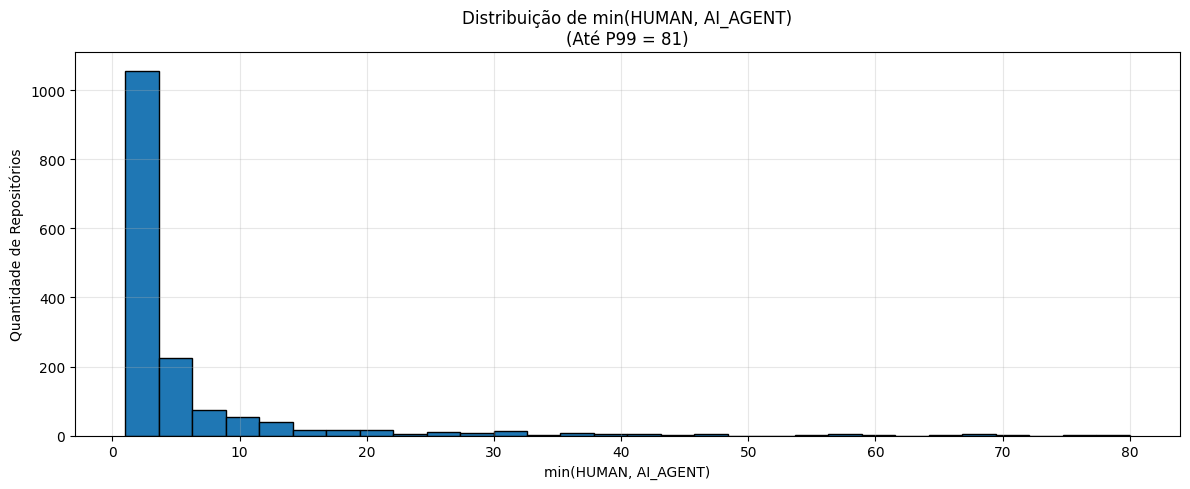

In [11]:
# ==========================
# Histograma (até o P99, para legibilidade)
# ==========================
q99 = counts["min_count"].quantile(0.99)
filtered = counts[counts["min_count"] <= q99]

plt.figure(figsize=(12, 5))
plt.hist(filtered["min_count"], bins=30, edgecolor="black")
plt.title(f"Distribuição de min(HUMAN, AI_AGENT)\n(Até P99 = {q99:.0f})")
plt.xlabel("min(HUMAN, AI_AGENT)")
plt.ylabel("Quantidade de Repositórios")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rq1_selecao_k_histograma.png", dpi=150, bbox_inches="tight")
plt.show()

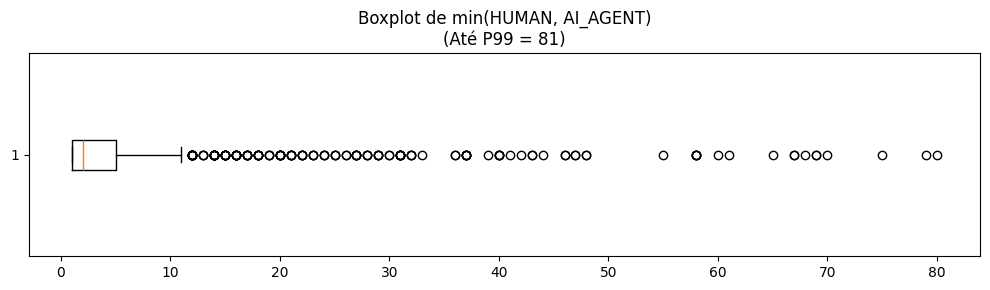

In [12]:
# ==========================
# Boxplot
# ==========================
plt.figure(figsize=(10, 3))
plt.boxplot(filtered["min_count"], vert=False)
plt.title(f"Boxplot de min(HUMAN, AI_AGENT)\n(Até P99 = {q99:.0f})")
plt.tight_layout()
plt.savefig("rq1_selecao_k_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

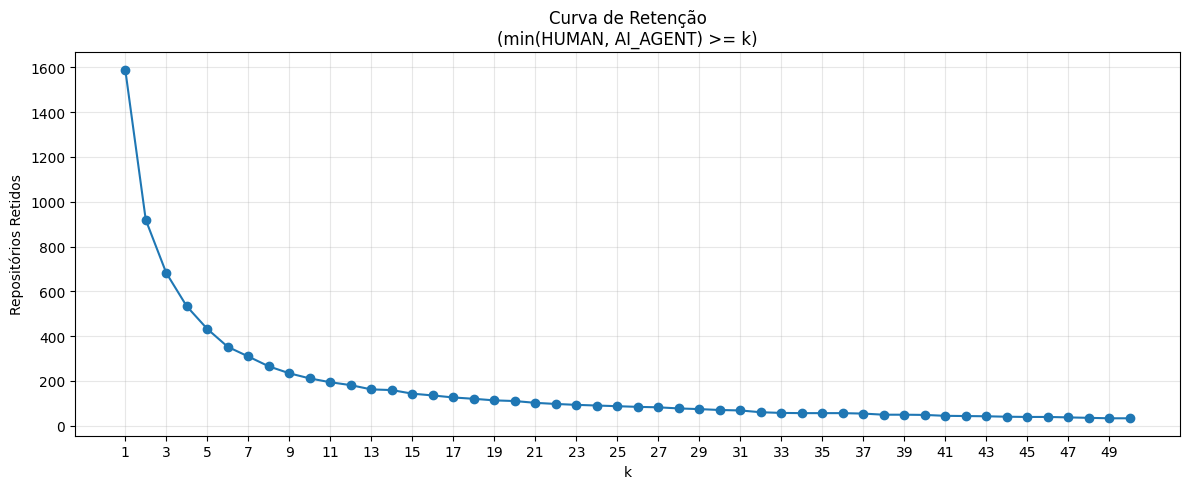


Retenção por k:

  k >=  1  ->  1590 repositórios  (100.0%)
  k >=  2  ->   919 repositórios  ( 57.8%)
  k >=  3  ->   682 repositórios  ( 42.9%)
  k >=  4  ->   533 repositórios  ( 33.5%)
  k >=  5  ->   432 repositórios  ( 27.2%)
  k >=  6  ->   352 repositórios  ( 22.1%)
  k >=  7  ->   309 repositórios  ( 19.4%)
  k >=  8  ->   265 repositórios  ( 16.7%)
  k >=  9  ->   234 repositórios  ( 14.7%)
  k >= 10  ->   211 repositórios  ( 13.3%)
  k >= 15  ->   143 repositórios  (  9.0%)
  k >= 20  ->   110 repositórios  (  6.9%)
  k >= 25  ->    87 repositórios  (  5.5%)
  k >= 30  ->    70 repositórios  (  4.4%)
  k >= 40  ->    48 repositórios  (  3.0%)
  k >= 50  ->    33 repositórios  (  2.1%)

Limiar principal adotado no estudo: k >= 3 (682 repositórios neste conjunto pré-filtros)


In [13]:
# ==========================
# Curva de retenção: repositórios retidos por limiar k
# ==========================
retention = pd.DataFrame([
    {"k": k, "repos": int((counts["min_count"] >= k).sum())}
    for k in range(1, 51)
])

plt.figure(figsize=(12, 5))
plt.plot(retention["k"], retention["repos"], marker="o")
plt.xticks(range(1, 51, 2))
plt.xlabel("k")
plt.ylabel("Repositórios Retidos")
plt.title("Curva de Retenção\n(min(HUMAN, AI_AGENT) >= k)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rq1_selecao_k_retencao.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabela detalhada de retenção
print("\nRetenção por k:\n")
for k in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 40, 50]:
    repos = int((counts["min_count"] >= k).sum())
    print(f"  k >= {k:2d}  ->  {repos:4d} repositórios  ({repos/len(counts)*100:5.1f}%)")

print(f"\nLimiar principal adotado no estudo: k >= {K_PRINCIPAL} "
      f"({int((counts['min_count'] >= K_PRINCIPAL).sum())} repositórios neste conjunto pré-filtros)")

In [14]:
# ==========================
# Comparação explícita: repositórios retidos por k, PRÉ vs PÓS filtros metodológicos
# ==========================
# PRÉ-filtros: o 'counts' desta seção (todos os PRs mergeados)
# PÓS-filtros: corpus final (merges reais), reconstruído a partir do CSV de esforço

d_pos = df_me[
    (df_me.pr_class.isin(["AI_AGENT", "HUMAN"])) &
    (df_me.has_internal_merge == 0) &
    (df_me.error_message.isna()) &
    (df_me.is_squash_merge == 0)
]
cnt_pos = d_pos.groupby(["repo_id", "pr_class"]).size().unstack(fill_value=0)
for col in ["HUMAN", "AI_AGENT"]:
    if col not in cnt_pos.columns:
        cnt_pos[col] = 0
cnt_pos = cnt_pos[(cnt_pos.HUMAN > 0) & (cnt_pos.AI_AGENT > 0)]
cnt_pos["min_count"] = cnt_pos[["HUMAN", "AI_AGENT"]].min(axis=1)

tabela_cmp = pd.DataFrame([
    {
        "k": k,
        "Pré-filtros (seleção de k)": int((counts["min_count"] >= k).sum()),
        "Pós-filtros (corpus final)": int((cnt_pos["min_count"] >= k).sum()),
    }
    for k in [1, 3, 5, 10]
])
print("=== Repositórios pareáveis: PRÉ vs PÓS filtros metodológicos ===")
print(tabela_cmp.to_string(index=False))
print("\nOs valores PÓS-filtros (487 / 150 / 95 / 39) são os que constam no")
print("funil PRISMA e na tabela de sensibilidade do artigo. Os valores PRÉ-filtros")
print("servem apenas para esta análise exploratória de seleção do limiar k.")

=== Repositórios pareáveis: PRÉ vs PÓS filtros metodológicos ===
 k  Pré-filtros (seleção de k)  Pós-filtros (corpus final)
 1                        1590                         487
 3                         682                         150
 5                         432                          95
10                         211                          39

Os valores PÓS-filtros (487 / 150 / 95 / 39) são os que constam no
funil PRISMA e na tabela de sensibilidade do artigo. Os valores PRÉ-filtros
servem apenas para esta análise exploratória de seleção do limiar k.


## 4.6. Efeito dos Filtros Metodológicos na Composição do Corpus

Os filtros metodológicos (\textit{squash}/\textit{rebase}, \textit{merge} interno e erros de
cálculo) reduzem o corpus de PRs mergeados ao subconjunto de \textit{merges} reais de dois pais.
Esta seção quantifica e visualiza esse efeito na composição do corpus, em três níveis:

1. **Efeito do filtro de \textit{merge} interno**, com destaque para a **assimetria entre as
   classes**: o \textit{merge} interno é substancialmente mais frequente em PRs humanos do que
   agênticos, fazendo o filtro removê-los de forma desproporcional.
2. **Distribuição das quantidades de PRs por repositório, antes e depois dos filtros**, para
   visualizar como o formato das distribuições (agêntica, humana e \textit{min}) se altera.
3. **Estatísticas descritivas das quantidades**, que documentam numericamente a mudança e
   determinam o **Q3 do `min(IA, Humano)`** — base para a escolha do limiar principal.
   No corpus pós-filtros, o Q3 dessa distribuição é **3**, motivando $k = 3$ como limiar
   principal (vs. Q3 = 5 sobre o conjunto pré-filtros).

> **Nota de reconciliação com o PRISMA.** Os números desta seção quantificam o efeito
> **isolado** do filtro de \textit{merge} interno, e portanto não correspondem diretamente
> às etapas da figura PRISMA de \textit{pull-requests}. A diferença é de **granularidade do
> filtro**, não de dados. No PRISMA, a etapa "*Sem \textit{merge} interno e erros*" agrupa
> três categorias de exclusão num único passo: PRs com \textit{merge} interno + PRs com outros
> erros de cálculo (\textit{merge\_sha} não encontrado, encoding, etc.) + PRs sem pais. Por
> isso, o PRISMA reporta uma redução de **1.242 PRs agênticos** (de 22.056 para 20.814) e
> **35.970 humanos** (de 538.325 para 502.355) nessa etapa. Já esta seção isola o filtro de
> \textit{merge} interno especificamente, removendo apenas os PRs com `has_internal_merge=1`
> e mantendo os demais erros de cálculo no conjunto "antes". O efeito isolado é de
> **488 PRs agênticos e 20.418 humanos** — exatamente os PRs do CSV com a mensagem de erro
> referente a \textit{merge} interno. Em ambos os casos, o número final de PRs no corpus
> analisável é o mesmo (7.646 agênticos / 74.292 humanos), porque todos os filtros são
> aplicados ao final.

In [15]:
# ==========================
# Efeito do filtro de merge interno: composição antes vs depois
# ==========================
ai_hu = df_me[df_me.pr_class.isin(["HUMAN", "AI_AGENT"])].copy()

# Separa o erro "merge interno" dos demais erros, para isolar o efeito do filtro
def _eh_erro_interno(m):
    return isinstance(m, str) and "interno" in m.lower()
ai_hu["err_outro"] = ai_hu.error_message.notna() & ~ai_hu.error_message.apply(_eh_erro_interno)

# ANTES: sem squash e sem outros erros, mas PERMITINDO merge interno
antes  = ai_hu[(ai_hu.is_squash_merge == 0) & (~ai_hu.err_outro)]
# DEPOIS: também remove merge interno
depois = antes[antes.has_internal_merge == 0]

# Tabela de composição
linhas = []
for cls in ["AI_AGENT", "HUMAN"]:
    a, d = antes[antes.pr_class == cls], depois[depois.pr_class == cls]
    linhas.append({
        "Classe": cls,
        "PRs (antes)": len(a), "PRs (depois)": len(d),
        "PRs removidos": len(a) - len(d),
        "% removido": round((len(a) - len(d)) / len(a) * 100, 1),
        "Repos (antes)": a.repo_id.nunique(), "Repos (depois)": d.repo_id.nunique(),
    })
comp_mi = pd.DataFrame(linhas)
print("=== Composição antes/depois do filtro de merge interno ===")
print(comp_mi.to_string(index=False))

# Incidência de merge interno dentro de cada classe
print("\n=== Incidência de merge interno por classe (entre PRs sem squash) ===")
base = ai_hu[ai_hu.is_squash_merge == 0]
for cls in ["AI_AGENT", "HUMAN"]:
    s = base[base.pr_class == cls]
    print(f"  {cls:9s}: {(s.has_internal_merge == 1).mean()*100:.1f}% têm merge interno")

=== Composição antes/depois do filtro de merge interno ===
  Classe  PRs (antes)  PRs (depois)  PRs removidos  % removido  Repos (antes)  Repos (depois)
AI_AGENT         8134          7646            488         6.0            658             634
   HUMAN        94710         74292          20418        21.6           1283            1227

=== Incidência de merge interno por classe (entre PRs sem squash) ===
  AI_AGENT : 5.5% têm merge interno
  HUMAN    : 18.5% têm merge interno


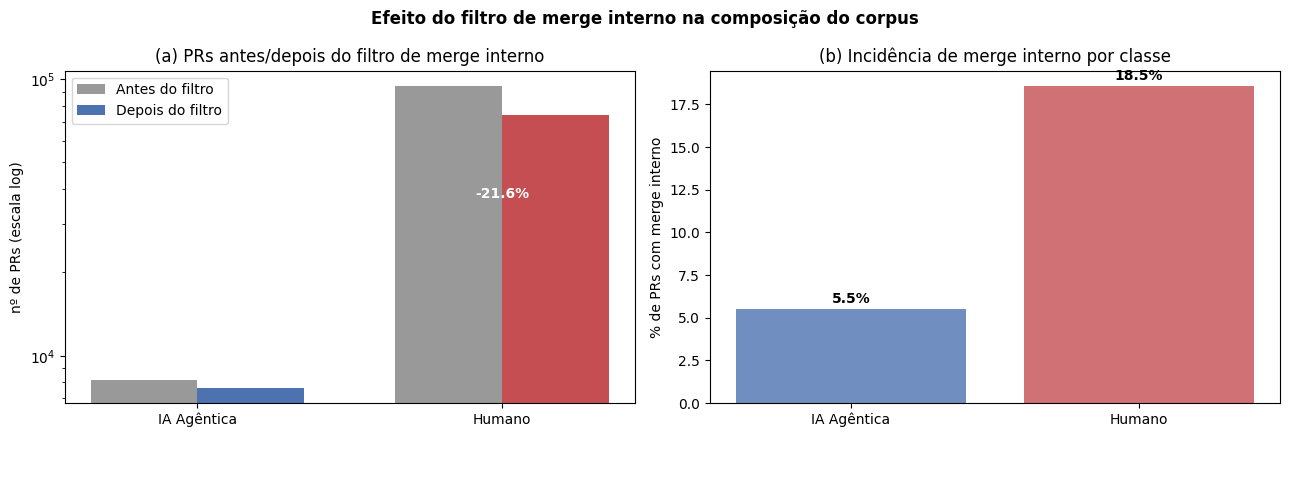

In [16]:
# ==========================
# Visualização do efeito do filtro
# ==========================
AI_COLOR, HU_COLOR = "#4C72B0", "#C44E52"
classes = ["AI_AGENT", "HUMAN"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# (a) PRs antes/depois por classe (escala log)
antes_pr  = [len(antes[antes.pr_class == c]) for c in classes]
depois_pr = [len(depois[depois.pr_class == c]) for c in classes]
x = np.arange(len(classes)); w = 0.35
ax1.bar(x - w/2, antes_pr,  w, label="Antes do filtro",  color="#999999")
ax1.bar(x + w/2, depois_pr, w, label="Depois do filtro", color=[AI_COLOR, HU_COLOR])
ax1.set_yscale("log")
ax1.set_xticks(x); ax1.set_xticklabels(["IA Agêntica", "Humano"])
ax1.set_ylabel("nº de PRs (escala log)")
ax1.set_title("(a) PRs antes/depois do filtro de merge interno")
ax1.legend()
for i, (a, d) in enumerate(zip(antes_pr, depois_pr)):
    ax1.text(i, d * 0.5, f"-{(a-d)/a*100:.1f}%", ha="center", fontweight="bold", color="white")

# (b) % de PRs com merge interno por classe
base = ai_hu[ai_hu.is_squash_merge == 0]
pct_mi = [(base[base.pr_class == c].has_internal_merge == 1).mean()*100 for c in classes]
ax2.bar(["IA Agêntica", "Humano"], pct_mi, color=[AI_COLOR, HU_COLOR], alpha=0.8)
ax2.set_ylabel("% de PRs com merge interno")
ax2.set_title("(b) Incidência de merge interno por classe")
for i, v in enumerate(pct_mi):
    ax2.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Efeito do filtro de merge interno na composição do corpus", fontweight="bold")
plt.tight_layout()
plt.savefig("rq1_merge_interno_efeito.png", dpi=150, bbox_inches="tight")
plt.savefig("rq1_merge_interno_efeito.pdf", bbox_inches="tight")
plt.show()

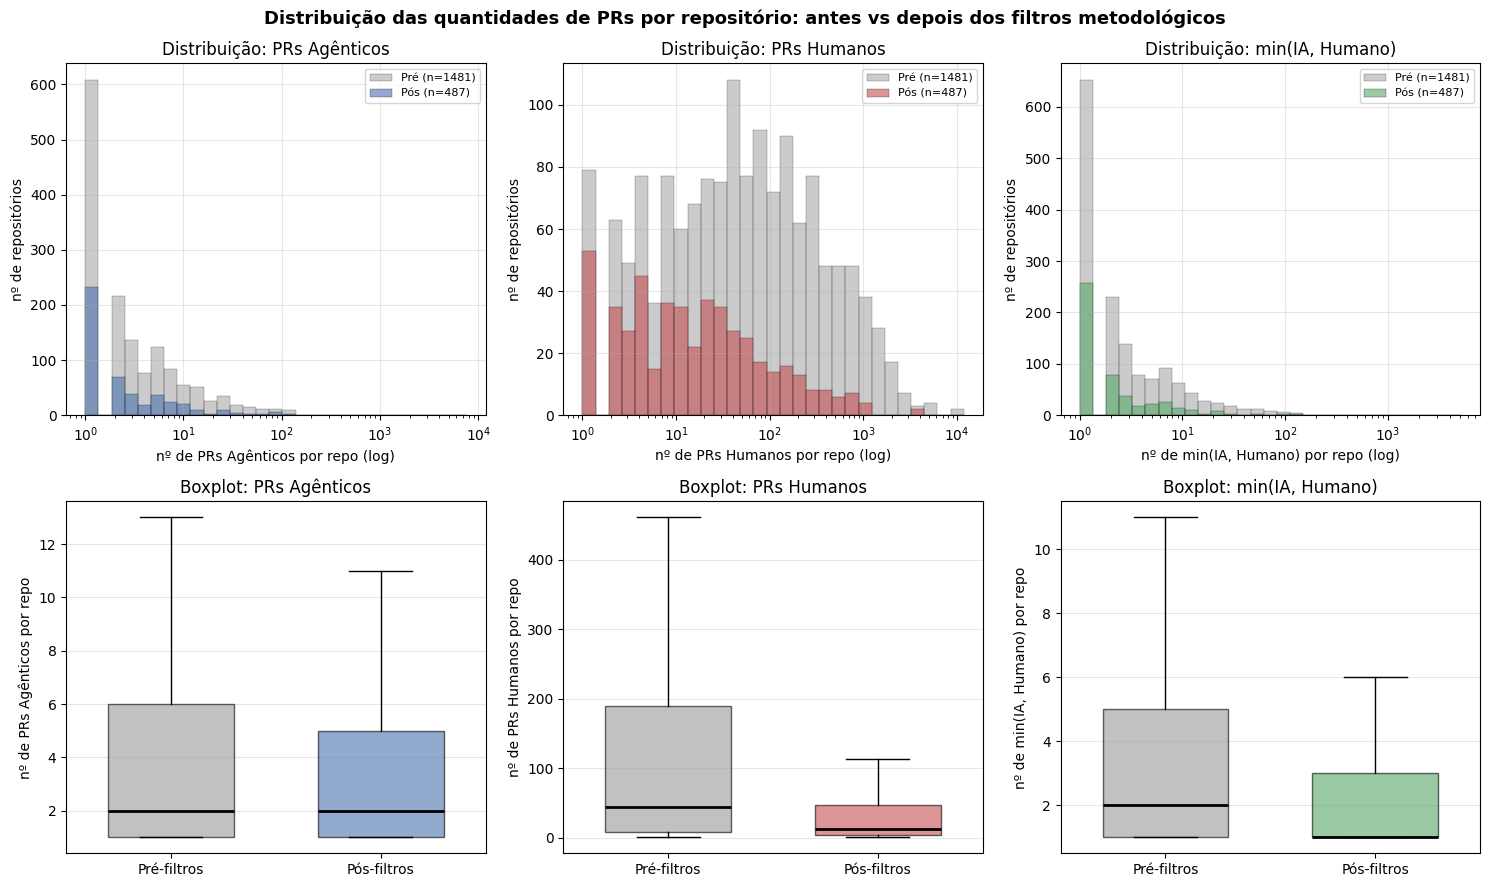

Estágio         Métrica  Mediana    Q3  Máximo  Média
    Pré   PRs Agênticos      2.0   6.0    7595   14.6
    Pré     PRs Humanos     45.0 190.0   11759  235.6
    Pré min(IA, Humano)      2.0   5.0    5129    9.5
    Pós   PRs Agênticos      2.0   5.0    3517   14.8
    Pós     PRs Humanos     13.0  48.0    4273   81.9
    Pós min(IA, Humano)      1.0   3.0     371    5.7


In [29]:
setting = "lin" # enum("log", "lin")
setting_showFliers = False

# ==========================
# Distribuições das QUANTIDADES de PRs por repositório: antes vs depois dos filtros
# ==========================
# PRÉ-filtros: todos os PRs mergeados das duas classes
ai_hu_all = df_me[df_me.pr_class.isin(["HUMAN", "AI_AGENT"])]

def _counts_pareados(d):
    c = d.groupby(["repo_id", "pr_class"]).size().unstack(fill_value=0)
    for col in ["HUMAN", "AI_AGENT"]:
        if col not in c.columns:
            c[col] = 0
    c = c[(c.HUMAN > 0) & (c.AI_AGENT > 0)]
    c["min_count"] = c[["HUMAN", "AI_AGENT"]].min(axis=1)
    return c

pre = _counts_pareados(ai_hu_all)
pos = _counts_pareados(df_me[(df_me.has_internal_merge == 0) &
                             (df_me.error_message.isna()) &
                             (df_me.is_squash_merge == 0) &
                             (df_me.pr_class.isin(["HUMAN", "AI_AGENT"]))])

AI_COLOR, HU_COLOR, MIN_COLOR, PRE_C = "#4C72B0", "#C44E52", "#55A868", "#999999"
metricas = [("AI_AGENT", AI_COLOR, "PRs Agênticos"),
            ("HUMAN", HU_COLOR, "PRs Humanos"),
            ("min_count", MIN_COLOR, "min(IA, Humano)")]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Linha 1 — histogramas sobrepostos (escala log)
for j, (col, cor, titulo) in enumerate(metricas):
    ax = axes[0, j]
    vmax = max(pre[col].max(), pos[col].max())
    bins = np.logspace(0, np.log10(vmax), 30)
    ax.hist(pre[col], bins=bins, alpha=0.5, label=f"Pré (n={len(pre)})",
            color=PRE_C, edgecolor="black", linewidth=0.3)
    ax.hist(pos[col], bins=bins, alpha=0.6, label=f"Pós (n={len(pos)})",
            color=cor, edgecolor="black", linewidth=0.3)
    ax.set_xscale("log")
    ax.set_xlabel(f"nº de {titulo} por repo (log)")
    ax.set_ylabel("nº de repositórios")
    ax.set_title(f"Distribuição: {titulo}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Linha 2 — boxplots comparativos (escala log no EIXO, dados crus)
for j, (col, cor, titulo) in enumerate(metricas):
    ax = axes[1, j]
    bp = ax.boxplot([pre[col], pos[col]],
                    tick_labels=["Pré-filtros", "Pós-filtros"],
                    patch_artist=True, widths=0.6, showfliers=setting_showFliers)
    for patch, c in zip(bp["boxes"], [PRE_C, cor]):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    for med in bp["medians"]:
        med.set_color("black"); med.set_linewidth(2)
    if setting == "log":
      ax.set_yscale("log")
      ax.set_ylabel(f"nº de {titulo} por repo (log)")
    else:
      ax.set_yscale("linear")
      ax.set_ylabel(f"nº de {titulo} por repo")
    ax.set_title(f"Boxplot: {titulo}")
    ax.grid(axis="y", alpha=0.3, which="both")

plt.suptitle("Distribuição das quantidades de PRs por repositório: "
             "antes vs depois dos filtros metodológicos",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("rq1_distribuicao_quantidades_pre_pos.png", dpi=150, bbox_inches="tight")
plt.savefig("rq1_distribuicao_quantidades_pre_pos.pdf", bbox_inches="tight")
plt.show()

# Resumo numérico das distribuições
resumo = []
for nome, c in [("Pré", pre), ("Pós", pos)]:
    for col, _, titulo in metricas:
        resumo.append({"Estágio": nome, "Métrica": titulo,
                       "Mediana": c[col].median(), "Q3": c[col].quantile(.75),
                       "Máximo": c[col].max(), "Média": round(c[col].mean(), 1)})
print(pd.DataFrame(resumo).to_string(index=False))

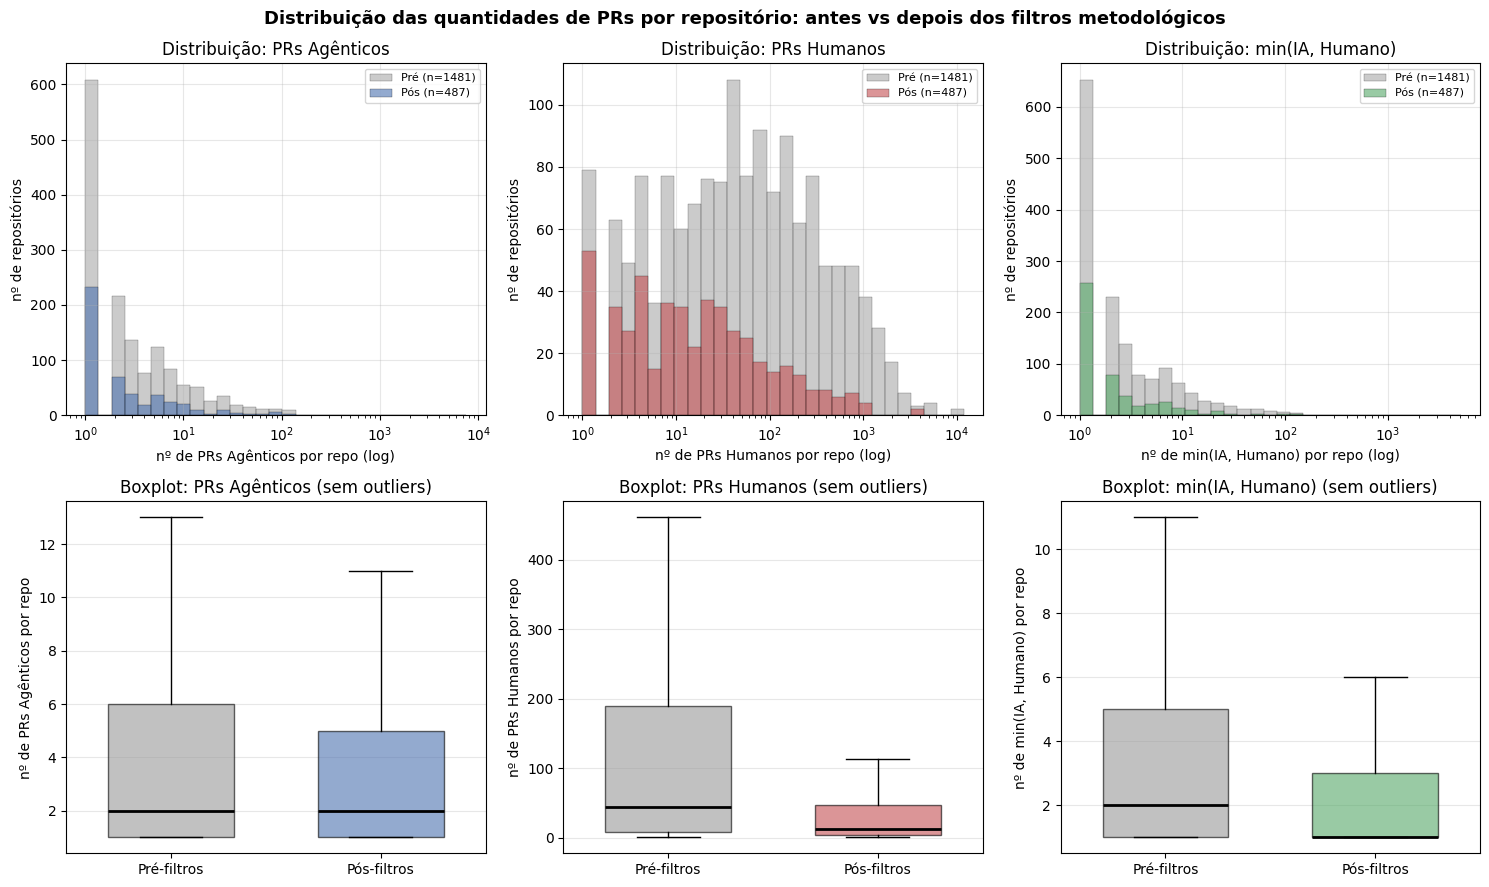

Estágio         Métrica  Mediana    Q3  Máximo  Média
    Pré   PRs Agênticos      2.0   6.0    7595   14.6
    Pré     PRs Humanos     45.0 190.0   11759  235.6
    Pré min(IA, Humano)      2.0   5.0    5129    9.5
    Pós   PRs Agênticos      2.0   5.0    3517   14.8
    Pós     PRs Humanos     13.0  48.0    4273   81.9
    Pós min(IA, Humano)      1.0   3.0     371    5.7


In [18]:
# ==========================
# Distribuições das QUANTIDADES de PRs por repositório: antes vs depois dos filtros
# ==========================
# PRÉ-filtros: todos os PRs mergeados das duas classes
ai_hu_all = df_me[df_me.pr_class.isin(["HUMAN", "AI_AGENT"])]

def _counts_pareados(d):
    c = d.groupby(["repo_id", "pr_class"]).size().unstack(fill_value=0)
    for col in ["HUMAN", "AI_AGENT"]:
        if col not in c.columns:
            c[col] = 0
    c = c[(c.HUMAN > 0) & (c.AI_AGENT > 0)]
    c["min_count"] = c[["HUMAN", "AI_AGENT"]].min(axis=1)
    return c

pre = _counts_pareados(ai_hu_all)
pos = _counts_pareados(df_me[(df_me.has_internal_merge == 0) &
                             (df_me.error_message.isna()) &
                             (df_me.is_squash_merge == 0) &
                             (df_me.pr_class.isin(["HUMAN", "AI_AGENT"]))])

AI_COLOR, HU_COLOR, MIN_COLOR, PRE_C = "#4C72B0", "#C44E52", "#55A868", "#999999"
metricas = [("AI_AGENT", AI_COLOR, "PRs Agênticos"),
            ("HUMAN", HU_COLOR, "PRs Humanos"),
            ("min_count", MIN_COLOR, "min(IA, Humano)")]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Linha 1 — histogramas sobrepostos (escala log)
for j, (col, cor, titulo) in enumerate(metricas):
    ax = axes[0, j]
    vmax = max(pre[col].max(), pos[col].max())
    bins = np.logspace(0, np.log10(vmax), 30)
    ax.hist(pre[col], bins=bins, alpha=0.5, label=f"Pré (n={len(pre)})",
            color=PRE_C, edgecolor="black", linewidth=0.3)
    ax.hist(pos[col], bins=bins, alpha=0.6, label=f"Pós (n={len(pos)})",
            color=cor, edgecolor="black", linewidth=0.3)
    ax.set_xscale("log")
    ax.set_xlabel(f"nº de {titulo} por repo (log)")
    ax.set_ylabel("nº de repositórios")
    ax.set_title(f"Distribuição: {titulo}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Linha 2 — boxplots comparativos (escala LINEAR, sem outliers)
for j, (col, cor, titulo) in enumerate(metricas):
    ax = axes[1, j]
    bp = ax.boxplot([pre[col], pos[col]],
                    tick_labels=["Pré-filtros", "Pós-filtros"],
                    patch_artist=True, widths=0.6, showfliers=False)
    for patch, c in zip(bp["boxes"], [PRE_C, cor]):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    for med in bp["medians"]:
        med.set_color("black"); med.set_linewidth(2)
    ax.set_ylabel(f"nº de {titulo} por repo")
    ax.set_title(f"Boxplot: {titulo} (sem outliers)")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Distribuição das quantidades de PRs por repositório: "
             "antes vs depois dos filtros metodológicos",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("rq1_distribuicao_quantidades_pre_pos.png", dpi=150, bbox_inches="tight")
plt.savefig("rq1_distribuicao_quantidades_pre_pos.pdf", bbox_inches="tight")
plt.show()

# Resumo numérico das distribuições
resumo = []
for nome, c in [("Pré", pre), ("Pós", pos)]:
    for col, _, titulo in metricas:
        resumo.append({"Estágio": nome, "Métrica": titulo,
                       "Mediana": c[col].median(), "Q3": c[col].quantile(.75),
                       "Máximo": c[col].max(), "Média": round(c[col].mean(), 1)})
print(pd.DataFrame(resumo).to_string(index=False))

In [19]:
# ==========================
# Q3 do min(IA, Humano) — base para a escolha do limiar k
# Responde à pergunta: o Q3 (que define o k principal) mudou com o filtro?
# ==========================
def _descritiva(s):
    return pd.Series({
        "Média": s.mean(), "Mediana": s.median(),
        "Q1": s.quantile(.25), "Q3": s.quantile(.75),
        "IQR": s.quantile(.75) - s.quantile(.25),
        "Desvio-Padrão": s.std(), "Mínimo": s.min(), "Máximo": s.max(),
        "% Zeros": (s == 0).mean() * 100, "Assimetria": s.skew(),
    })

desc = pd.DataFrame({
    "Agêntico (pré)":  _descritiva(pre["AI_AGENT"]),
    "Agêntico (pós)":  _descritiva(pos["AI_AGENT"]),
    "Humano (pré)":    _descritiva(pre["HUMAN"]),
    "Humano (pós)":    _descritiva(pos["HUMAN"]),
    "min (pré)":       _descritiva(pre["min_count"]),
    "min (pós)":       _descritiva(pos["min_count"]),
}).round(2)
print("=== Quantidades de PRs por repositório: descritiva pré vs pós-filtros ===")
print(desc.to_string())

# Q3 do min(IA, Humano) — métrica decisiva para o limiar k
q3_min_pre = pre["min_count"].quantile(.75)
q3_min_pos = pos["min_count"].quantile(.75)
print(f"\n--- Limiar principal (k = Q3 do min(IA, Humano)) ---")
print(f"Q3 do min(IA, Humano) PRÉ-filtros:  {q3_min_pre:.0f}")
print(f"Q3 do min(IA, Humano) PÓS-filtros:  {q3_min_pos:.0f}  (corpus efetivamente analisado)")
print(f"\nO Q3 do min(IA, Humano) cai de {q3_min_pre:.0f} para {q3_min_pos:.0f} com a aplicação")
print(f"dos filtros metodológicos. Adotamos k = {q3_min_pos:.0f} como limiar principal,")
print(f"refletindo o Q3 da distribuição efetivamente analisada (pós-filtros).")

=== Quantidades de PRs por repositório: descritiva pré vs pós-filtros ===
               Agêntico (pré)  Agêntico (pós)  Humano (pré)  Humano (pós)  min (pré)  min (pós)
Média                   14.58           14.75        235.61         81.91       9.49       5.73
Mediana                  2.00            2.00         45.00         13.00       2.00       1.00
Q1                       1.00            1.00          9.00          4.00       1.00       1.00
Q3                       6.00            5.00        190.00         48.00       5.00       3.00
IQR                      5.00            4.00        181.00         44.00       4.00       2.00
Desvio-Padrão          218.02          161.00        645.95        295.39     134.39      25.44
Mínimo                   1.00            1.00          1.00          1.00       1.00       1.00
Máximo                7595.00         3517.00      11759.00       4273.00    5129.00     371.00
% Zeros                  0.00            0.00          0.00   

## 4.7. Sensibilidade aos Filtros Metodológicos: o Efeito é Conservador?

A Seção 4.6 mostrou que os filtros metodológicos (exclusão de *merge* interno e *squash*)
alteram a **composição** do corpus. Resta a pergunta levantada na orientação: e o
**resultado**? A aplicação dos filtros fortalece ou enfraquece a evidência a favor da
hipótese (IA introduz menos esforço de *merge*)?

Para responder, reaplica-se a análise pareada completa em dois cenários --- **com** e
**sem** os filtros metodológicos --- mantendo o mesmo limiar principal ($k \geq 3$) e
comparando o tamanho de efeito (*rank-biserial*) e a proporção de evidência favorável.

> **Nota interpretativa.** Sem os filtros, dois fenômenos se misturam: (i) a amostra muda
> de composição (entram repositórios antes excluídos, com perfil de menor esforço), e
> (ii) os *merges* internos passam a mascarar parte do esforço humano --- pois ações da
> *main* trazidas para dentro do PR fazem com que o esforço já tenha sido ``gasto'' antes
> do *merge* externo que medimos. O objetivo aqui não é isolar essas causas, mas verificar
> a **direção** do efeito agregado sobre a conclusão.

In [20]:
# ==========================
# Sensibilidade aos filtros: resultado COM vs SEM filtros metodológicos
# ==========================
from scipy.stats import wilcoxon, rankdata

def _build_paired(apply_filters):
    """Reconstrói o pareado por repositório COM ou SEM os filtros metodológicos."""
    base = df_me[df_me.pr_class.isin(["AI_AGENT", "HUMAN"]) & df_me.error_message.isna()]
    if apply_filters:
        base = base[(base.has_internal_merge == 0) & (base.is_squash_merge == 0)]
    rm = base.groupby(["repo_id", "pr_class"])["extra_effort"].mean().unstack("pr_class")
    rc = base.groupby(["repo_id", "pr_class"]).size().unstack("pr_class").fillna(0).astype(int)
    p = rm.join(rc, lsuffix="_m", rsuffix="_n")
    p.columns = ["ai", "hu", "ai_n", "hu_n"]
    return p.dropna(subset=["ai", "hu"]).copy()

def _resultado(sub):
    """Wilcoxon + rank-biserial + % favorável para um corpus pareado."""
    d = (sub.ai - sub.hu).values
    d_nz = d[d != 0]
    W, pval = wilcoxon(sub.ai, sub.hu)
    r = rankdata(np.abs(d_nz))
    r_plus, r_minus = r[d_nz > 0].sum(), r[d_nz < 0].sum()
    rb = (r_minus - r_plus) / r.sum()          # positivo = favorável (IA < HU)
    favoravel = (d_nz < 0).mean() * 100
    return len(sub), W, pval, rb, favoravel, len(d_nz)

K = K_PRINCIPAL
linhas = []
for label, apply_f in [("Com filtros (principal)", True), ("Sem filtros", False)]:
    p = _build_paired(apply_f)
    sub = p[(p.ai_n >= K) & (p.hu_n >= K)]
    n, W, pval, rb, fav, n_nz = _resultado(sub)
    linhas.append({
        "Cenário": label, "n repos": n, "Pares não nulos": n_nz,
        "Wilcoxon W": round(W, 1), "p": f"{pval:.2e}",
        "rank-biserial": round(rb, 3), "% favorável": round(fav, 1),
    })

comp = pd.DataFrame(linhas).set_index("Cenário")
print(f"=== Resultado COM vs SEM filtros metodológicos (k >= {K}) ===\n")
print(comp.to_string())

# Conclusão direcional
rb_com = comp.loc["Com filtros (principal)", "rank-biserial"]
rb_sem = comp.loc["Sem filtros", "rank-biserial"]
print(f"\nrank-biserial: {rb_com} (com filtros) vs {rb_sem} (sem filtros)")
if rb_sem > rb_com:
    print("=> Sem os filtros, o efeito a favor da IA seria AINDA MAIOR.")
    print("   A aplicação dos filtros é, portanto, CONSERVADORA em relação à hipótese:")
    print("   não infla o resultado; se algo, atenua-o. A decisão metodológica de excluir")
    print("   merges internos (em vez de ignorá-los) fortalece a credibilidade do achado.")
else:
    print("=> Os filtros não atenuam o efeito; ver composição da amostra na Seção 4.6.")

=== Resultado COM vs SEM filtros metodológicos (k >= 3) ===

                         n repos  Pares não nulos  Wilcoxon W         p  rank-biserial  % favorável
Cenário                                                                                            
Com filtros (principal)      150               99       820.0  7.63e-09          0.669         83.8
Sem filtros                  551              285      5988.5  5.01e-25          0.706         89.8

rank-biserial: 0.669 (com filtros) vs 0.706 (sem filtros)
=> Sem os filtros, o efeito a favor da IA seria AINDA MAIOR.
   A aplicação dos filtros é, portanto, CONSERVADORA em relação à hipótese:
   não infla o resultado; se algo, atenua-o. A decisão metodológica de excluir
   merges internos (em vez de ignorá-los) fortalece a credibilidade do achado.


## 5. Análise Pareada por Repositório (*Macro Averaged Mean*)

Cada repositório contribui com um par de médias (agêntica e humana) do esforço de merge.
O corpus final (merges reais) é agregado por repositório.

In [21]:
# Conjunto final de análise: merges reais (pai duplo), sem BOT e sem erros
df_final = d3.copy()
print(f"Corpus final: {len(df_final):,} PRs "
      f"({(df_final.pr_class=='AI_AGENT').sum():,} agênticos, "
      f"{(df_final.pr_class=='HUMAN').sum():,} humanos)")

# Macro Averaged Mean: média de extra_effort por (repo, classe)
repo_means  = df_final.groupby(["repo_id", "pr_class"])["extra_effort"].mean().unstack("pr_class")
repo_counts = df_final.groupby(["repo_id", "pr_class"]).size().unstack("pr_class").fillna(0).astype(int)

paired = repo_means.join(repo_counts, lsuffix="_m", rsuffix="_n")
paired.columns = ["ai", "hu", "ai_n", "hu_n"]
paired = paired.dropna(subset=["ai", "hu"]).copy()
paired["dif"] = paired["ai"] - paired["hu"]   # negativo => IA gera MENOS esforço

print(f"Repositórios pareáveis (>=1 PR de cada classe): {len(paired)}")
paired.head()

Corpus final: 81,938 PRs (7,646 agênticos, 74,292 humanos)
Repositórios pareáveis (>=1 PR de cada classe): 487


,ai,hu,ai_n,hu_n,dif
repo_id,,,,,
122162,0.0,0.000000,15,1,0.000000
184366,0.0,0.000000,1,27,0.000000
509028,0.0,0.013699,5,73,-0.013699
521583,0.0,0.000000,1,418,0.000000
1181779,0.0,0.000000,3,2,0.000000


## 5.5. Distribuição do Esforço de Merge por Repositório

Antes dos testes estatísticos, é importante visualizar a distribuição do esforço de merge
médio em cada corpus (agêntico e humano), para entender sua forma e justificar as escolhas
metodológicas. Dada a forte assimetria e a alta concentração de zeros (sobretudo no corpus
agêntico), apresentam-se duas perspectivas complementares: uma em escala logarítmica
(forma geral da distribuição) e outra em escala linear sem os \textit{outliers} extremos
(corpo da distribuição: medianas e quartis).

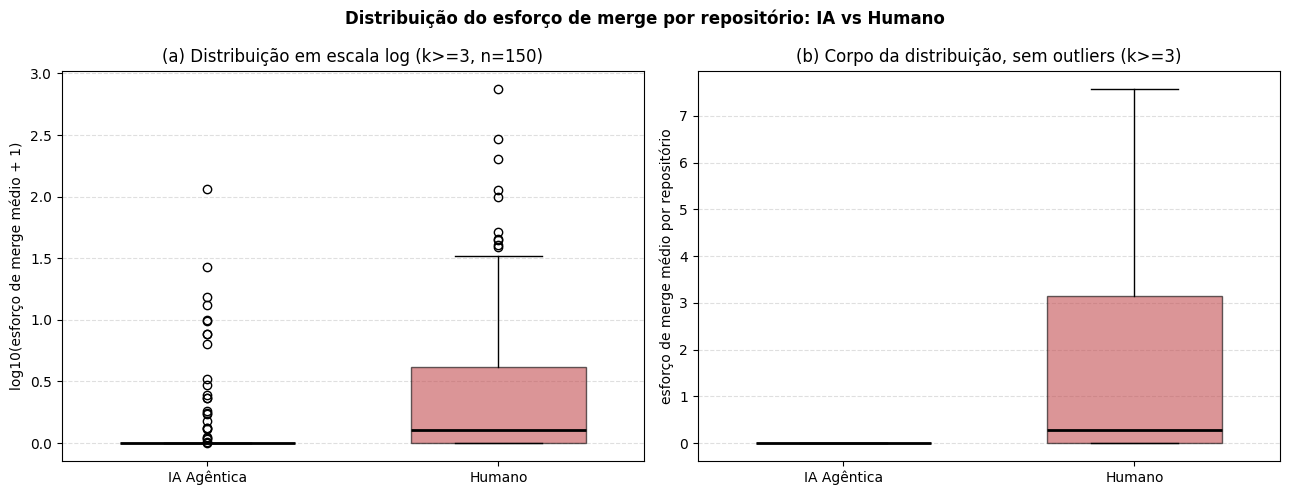

         IA Agêntica  Humano
Mínimo          0.00    0.00
Q1              0.00    0.00
Mediana         0.00    0.28
Q3              0.00    3.14
Máximo        115.00  753.67
% zeros        82.67   38.00


In [22]:
# ==========================
# Boxplots comparativos do esforço de merge por repositório (k >= K_PRINCIPAL)
# ==========================
K = K_PRINCIPAL
sub = paired[(paired.ai_n >= K) & (paired.hu_n >= K)]

AI_COLOR, HU_COLOR = "#4C72B0", "#C44E52"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# (a) Escala log: log10(x + 1) preserva os zeros e revela a forma
bp1 = ax1.boxplot([np.log10(sub.ai + 1), np.log10(sub.hu + 1)],
                  tick_labels=["IA Agêntica", "Humano"],
                  patch_artist=True, widths=0.6)
for patch, cor in zip(bp1["boxes"], [AI_COLOR, HU_COLOR]):
    patch.set_facecolor(cor); patch.set_alpha(0.6)
for med in bp1["medians"]:
    med.set_color("black"); med.set_linewidth(2)
ax1.set_ylabel("log10(esforço de merge médio + 1)")
ax1.set_title(f"(a) Distribuição em escala log (k>={K}, n={len(sub)})")
ax1.grid(axis="y", ls="--", alpha=0.4)

# (b) Escala linear, sem outliers: foco no corpo (mediana, IQR)
bp2 = ax2.boxplot([sub.ai, sub.hu],
                  tick_labels=["IA Agêntica", "Humano"],
                  patch_artist=True, widths=0.6, showfliers=False)
for patch, cor in zip(bp2["boxes"], [AI_COLOR, HU_COLOR]):
    patch.set_facecolor(cor); patch.set_alpha(0.6)
for med in bp2["medians"]:
    med.set_color("black"); med.set_linewidth(2)
ax2.set_ylabel("esforço de merge médio por repositório")
ax2.set_title(f"(b) Corpo da distribuição, sem outliers (k>={K})")
ax2.grid(axis="y", ls="--", alpha=0.4)

plt.suptitle("Distribuição do esforço de merge por repositório: IA vs Humano",
             fontweight="bold")
plt.tight_layout()
plt.savefig("rq1_boxplot_distribuicao.png", dpi=150, bbox_inches="tight")
plt.savefig("rq1_boxplot_distribuicao.pdf", bbox_inches="tight")
plt.show()

# Resumo numérico das duas distribuições
resumo = pd.DataFrame({
    "IA Agêntica": [sub.ai.min(), sub.ai.quantile(.25), sub.ai.median(),
                    sub.ai.quantile(.75), sub.ai.max(), (sub.ai == 0).mean()*100],
    "Humano":      [sub.hu.min(), sub.hu.quantile(.25), sub.hu.median(),
                    sub.hu.quantile(.75), sub.hu.max(), (sub.hu == 0).mean()*100],
}, index=["Mínimo", "Q1", "Mediana", "Q3", "Máximo", "% zeros"]).round(2)
print(resumo.to_string())

## 6. Testes Estatísticos e Sensibilidade ao *k*

Para cada limiar $k \in \{1, 3, 5, 10\}$, executa-se:

- **Shapiro-Wilk** para verificar normalidade de cada amostra (esperado: não-normalidade);
- **Wilcoxon \textit{signed-rank}** pareado por repositório (hipótese alternativa: o esforço
  de merge agêntico é menor que o humano);
- **rank-biserial pareado** como medida de magnitude do efeito (dominância da evidência
  favorável; Kerby, 2014).

> **Sobre correção para múltiplas comparações.** Os quatro valores de *k* representam uma
> análise de sensibilidade — subconjuntos aninhados dos mesmos dados, e não comparações
> independentes —, portanto **não se aplica** correção de múltiplas comparações
> (Holm, Bonferroni, etc.). Reportam-se os $p$-valores **brutos** do Wilcoxon. A análise
> de sensibilidade serve apenas para verificar a robustez do achado à escolha do limiar,
> não para contar testes simultâneos.

In [23]:
# ==========================
# Análise de sensibilidade ao limiar k: Shapiro + Wilcoxon + rank-biserial (sem correção)
# ==========================
from scipy.stats import wilcoxon, shapiro, rankdata

def _rank_biserial_pareado(d):
    """Calcula rank-biserial pareado e % de evidência favorável.
    Sinal positivo = favorável à hipótese (ai < hu)."""
    diff = d.ai - d.hu
    nz = diff[diff != 0]
    if len(nz) == 0:
        return 0.0, 50.0
    absdiff = nz.abs()
    ranks = rankdata(absdiff)
    sign = np.sign(nz.values)
    R_pos = ranks[sign > 0].sum()  # ai > hu (desfavorável)
    R_neg = ranks[sign < 0].sum()  # ai < hu (favorável)
    R_tot = ranks.sum()
    r = (R_neg - R_pos) / R_tot
    pct_fav = R_neg / R_tot * 100
    return r, pct_fav

linhas = []
for k in [1, 3, 5, 10]:
    sub = paired[(paired.ai_n >= k) & (paired.hu_n >= k)].copy()
    diff = sub.ai - sub.hu
    nn = int((diff != 0).sum())
    ai_menor = int((diff < 0).sum())   # repos em que AI < HU (favorável)
    ai_maior = int((diff > 0).sum())   # repos em que AI > HU (desfavorável)
    sw_ai, sp_ai = shapiro(sub.ai)
    sw_hu, sp_hu = shapiro(sub.hu)
    W, p = wilcoxon(sub.ai, sub.hu, alternative="less", zero_method="wilcox")
    r, pct_fav = _rank_biserial_pareado(sub)
    linhas.append({
        "k": k,
        "n_repos": len(sub),
        "pares_nao_nulos": nn,
        "AI_menor": ai_menor,
        "AI_maior": ai_maior,
        "shapiro_ai_p": sp_ai,
        "shapiro_hu_p": sp_hu,
        "wilcoxon_W": round(W, 1),
        "wilcoxon_p": p,
        "rank_biserial": round(r, 3),
        "pct_evidencia_favoravel": round(pct_fav, 1),
    })

resultados = pd.DataFrame(linhas)
print("=== Análise de sensibilidade ao limiar k (sem correção de múltiplas comparações) ===")
print(resultados.to_string(index=False))
print(f"\nLimiar principal: k >= {K_PRINCIPAL} (Q3 do min(IA, Humano) pós-filtros).")
print("p-valores são brutos: os limiares são subconjuntos aninhados dos mesmos dados,")
print("portanto não se aplica correção de múltiplas comparações.")

=== Análise de sensibilidade ao limiar k (sem correção de múltiplas comparações) ===
 k  n_repos  pares_nao_nulos  AI_menor  AI_maior  shapiro_ai_p  shapiro_hu_p  wilcoxon_W   wilcoxon_p  rank_biserial  pct_evidencia_favoravel
 1      487              245       212        33  1.477727e-43  2.111727e-41      4617.5 2.459676e-21          0.694                     84.7
 3      150               99        83        16  5.880969e-26  2.345709e-25       820.0 3.815021e-09          0.669                     83.4
 5       95               70        57        13  7.353853e-21  1.061206e-20       459.0 2.267816e-06          0.631                     81.5
10       39               32        25         7  1.395489e-10  3.297543e-12       113.0 2.374826e-03          0.572                     78.6

Limiar principal: k >= 3 (Q3 do min(IA, Humano) pós-filtros).
p-valores são brutos: os limiares são subconjuntos aninhados dos mesmos dados,
portanto não se aplica correção de múltiplas comparações.


In [24]:
# Exibição formatada (notação científica preservada nos p-valores)
disp = resultados.copy()
for c in ["shapiro_ai_p", "shapiro_hu_p", "wilcoxon_p"]:
    disp[c] = disp[c].apply(lambda x: f"{x:.2e}")
print(disp.to_string(index=False))

 k  n_repos  pares_nao_nulos  AI_menor  AI_maior shapiro_ai_p shapiro_hu_p  wilcoxon_W wilcoxon_p  rank_biserial  pct_evidencia_favoravel
 1      487              245       212        33     1.48e-43     2.11e-41      4617.5   2.46e-21          0.694                     84.7
 3      150               99        83        16     5.88e-26     2.35e-25       820.0   3.82e-09          0.669                     83.4
 5       95               70        57        13     7.35e-21     1.06e-20       459.0   2.27e-06          0.631                     81.5
10       39               32        25         7     1.40e-10     3.30e-12       113.0   2.37e-03          0.572                     78.6


## 7. Tabela Descritiva e Achado 1

Estatística descritiva do esforço de merge médio por repositório no limiar principal (`k>=3`)
e síntese do Achado 1.

In [25]:
K = K_PRINCIPAL
sub_k = paired[(paired.ai_n >= K) & (paired.hu_n >= K)]

def descritiva(serie):
    return pd.Series({
        "Média": serie.mean(), "Mediana": serie.median(),
        "Q1": serie.quantile(.25), "Q3": serie.quantile(.75),
        "IQR": serie.quantile(.75) - serie.quantile(.25),
        "Desvio Padrão": serie.std(), "Mínimo": serie.min(), "Máximo": serie.max(),
        "% Zeros": (serie == 0).mean() * 100, "Assimetria": serie.skew(),
    })

tabela_desc = pd.DataFrame({
    "Agentic": descritiva(sub_k["ai"]),
    "Humano":  descritiva(sub_k["hu"]),
}).round(2)
print(f"=== Esforço de merge médio por repositório (k>={K}, n={len(sub_k)}) ===")
tabela_desc

=== Esforço de merge médio por repositório (k>=3, n=150) ===


,Agentic,Humano
Média,1.44,13.08
Mediana,0.00,0.28
Q1,0.00,0.00
Q3,0.00,3.14
IQR,0.00,3.14
Desvio Padrão,9.77,68.72
Mínimo,0.00,0.00
Máximo,115.00,753.67
% Zeros,82.67,38.00
Assimetria,10.82,9.14


In [26]:
# --- Síntese do Achado 1 ---
linha_k = resultados[resultados.k == K_PRINCIPAL].iloc[0]
print("="*60)
print("ACHADO 1 (k >= %d, n = %d repositórios)" % (K_PRINCIPAL, int(linha_k.n_repos)))
print("="*60)
print(f"Wilcoxon signed-rank:  W = {linha_k.wilcoxon_W:.1f}, "
      f"p (bruto) = {linha_k.wilcoxon_p:.2e}")
print(f"Rank-biserial (efeito): r = {linha_k.rank_biserial:.3f}")
print(f"Evidência favorável à hipótese (IA < esforço): "
      f"{linha_k.pct_evidencia_favoravel:.1f}%")
print(f"Repositórios: IA menor em {int(linha_k.AI_menor)}, "
      f"humano menor em {int(linha_k.AI_maior)} "
      f"(de {int(linha_k.pares_nao_nulos)} com diferença não nula)")
print("-"*60)
print("Conclusão: os PRs gerados por IA introduzem consistentemente MENOS")
print("esforço de merge no repositório do que os PRs humanos, com efeito")
print("robusto à variação do limiar k (r entre %.2f e %.2f)." % (
    resultados.rank_biserial.min(), resultados.rank_biserial.max()))

ACHADO 1 (k >= 3, n = 150 repositórios)
Wilcoxon signed-rank:  W = 820.0, p (bruto) = 3.82e-09
Rank-biserial (efeito): r = 0.669
Evidência favorável à hipótese (IA < esforço): 83.4%
Repositórios: IA menor em 83, humano menor em 16 (de 99 com diferença não nula)
------------------------------------------------------------
Conclusão: os PRs gerados por IA introduzem consistentemente MENOS
esforço de merge no repositório do que os PRs humanos, com efeito
robusto à variação do limiar k (r entre 0.57 e 0.69).


## 8. Visualização — Dominância Pareada por Repositório

Slopegraph das médias por repositório (escala log) no limiar principal: cada linha é um
repositório, ligando sua média agêntica à humana. A cor indica a direção da diferença.

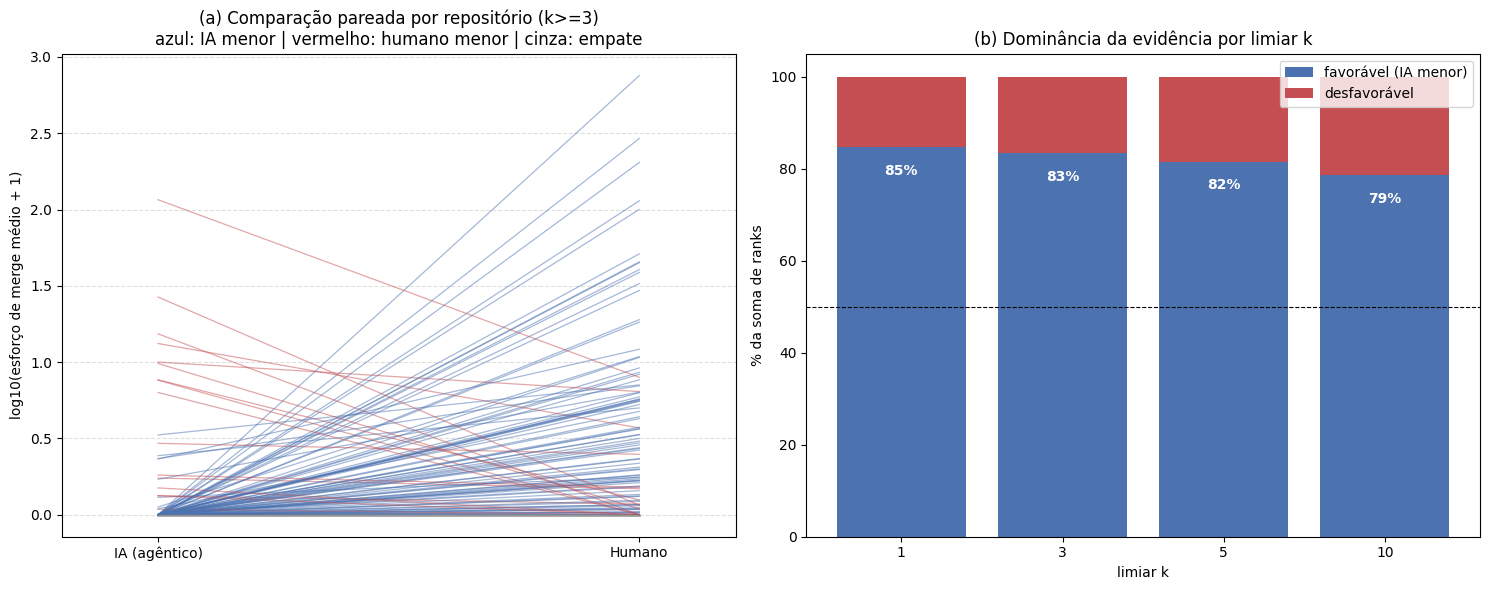

In [27]:
K = K_PRINCIPAL
sub = paired[(paired.ai_n >= K) & (paired.hu_n >= K)].copy()
sub["ai_log"] = np.log10(sub["ai"] + 1)
sub["hu_log"] = np.log10(sub["hu"] + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# (a) Slopegraph
for _, r in sub.iterrows():
    if r["ai"] < r["hu"]:   cor, a = "#4C72B0", 0.5   # IA menor (favorável)
    elif r["ai"] > r["hu"]: cor, a = "#C44E52", 0.5   # humano menor
    else:                   cor, a = "#999999", 0.2   # empate
    ax1.plot([0, 1], [r["ai_log"], r["hu_log"]], color=cor, alpha=a, lw=0.9)
ax1.set_xlim(-0.2, 1.2); ax1.set_xticks([0, 1])
ax1.set_xticklabels(["IA (agêntico)", "Humano"])
ax1.set_ylabel("log10(esforço de merge médio + 1)")
ax1.set_title(f"(a) Comparação pareada por repositório (k>={K})\n"
              "azul: IA menor | vermelho: humano menor | cinza: empate")
ax1.grid(axis="y", ls="--", alpha=0.4)

# (b) Barras de dominância por k
ax2.bar(resultados.k.astype(str), resultados.pct_evidencia_favoravel,
        color="#4C72B0", label="favorável (IA menor)")
ax2.bar(resultados.k.astype(str), 100 - resultados.pct_evidencia_favoravel,
        bottom=resultados.pct_evidencia_favoravel, color="#C44E52",
        label="desfavorável")
ax2.axhline(50, color="black", ls="--", lw=0.8)
ax2.set_xlabel("limiar k"); ax2.set_ylabel("% da soma de ranks")
ax2.set_title("(b) Dominância da evidência por limiar k")
ax2.legend()
for i, v in enumerate(resultados.pct_evidencia_favoravel):
    ax2.text(i, v - 6, f"{v:.0f}%", ha="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

---
### Notas de reprodutibilidade

- **Corpus final (RQ1):** 7.646 PRs agênticos / 74.292 humanos, em merges reais de dois pais.
- **Limiar principal:** `k>=3` (150 repositórios pareados), correspondente ao Q3 da
  distribuição de `min(IA, Humano)` no corpus pós-filtros.
- **Resultado central:** Wilcoxon significativo (p-valores brutos) em todos os `k`;
  rank-biserial entre 0,57 e 0,69, com 78–85% da evidência favorável à hipótese de menor
  esforço agêntico. Em `k>=3` (principal): r=0,67, p≈3,8×10⁻⁹, 83,4% favorável.
- **Sem correção de múltiplas comparações:** os limiares são subconjuntos aninhados dos
  mesmos dados — análise de sensibilidade, não comparações independentes —, portanto não
  se aplica correção (Holm, Bonferroni, etc.).
- **Referência do efeito:** Kerby, D. S. (2014). *The simple difference formula: An approach
  to teaching nonparametric correlation.* Para o rótulo de magnitude ("grande"), os limiares
  do *Cliff's delta* aplicáveis ao *rank-biserial* pareado vêm de Meissel & Yao (2024):
  ≥0,47 = grande. Todos os valores observados (r ∈ [0,57; 0,69]) ficam na faixa "grande".